In [24]:
import json
import hashlib
import shutil
from pathlib import Path

# Enterprise folder
attack_folder = Path(
    r"C:\Users\BIT\Downloads\attack-stix-data-master\attack-stix-data-master\enterprise-attack"
)

# Project data folder
data_folder = Path("../data")
data_folder.mkdir(exist_ok=True)

# Copy all JSON files
json_files = list(attack_folder.glob("*.json"))

for file in json_files:
    shutil.copy(file, data_folder / file.name)

# Dataset statistics
total_objects = 0
total_size = 0

for file in json_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        total_objects += len(data.get("objects", []))

    total_size += file.stat().st_size

# SHA256
sha = hashlib.sha256(
    "".join(sorted([f.name for f in json_files])).encode()
).hexdigest()

print("=== DATASET INFORMATION ===")
print("JSON Files :", len(json_files))
print("Objects    :", total_objects)
print("SHA256     :", sha)
print(f"Size       : {total_size/1e6:.1f} MB")
print(f"Copied     : {len(json_files)} files to data folder")

=== DATASET INFORMATION ===
JSON Files : 41
Objects    : 626511
SHA256     : 879fc576996d47bceae59fcce069c74ada0c18abb0cd31b4c238e2dc45a8ad64
Size       : 1252.9 MB
Copied     : 41 files to data folder


In [25]:
import json
import pathlib
import warnings
from collections import defaultdict, Counter

import numpy as np
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
ROOT       = pathlib.Path("..").resolve()
DATA_DIR   = ROOT / "data"
ARTIFACTS  = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

BUNDLE_FILES = sorted(DATA_DIR.glob("enterprise-attack-*.json"))
USE_ROOT_TECHNIQUE_ONLY = True

print(f"Enterprise files : {len(BUNDLE_FILES)}")
print(f"Artifacts   : {ARTIFACTS}")
print(f"Root techniques only: {USE_ROOT_TECHNIQUE_ONLY}")

Enterprise files : 40
Artifacts   : C:\Users\BIT\APT-Attribution-Engine\artifacts
Root techniques only: True


In [26]:
all_objects = []

for file in BUNDLE_FILES:
    with open(file, encoding="utf-8") as f:
        bundle = json.load(f)
        all_objects.extend(bundle.get("objects", []))

objects = all_objects
# ── partition by type ─────────────────────────────────────────
by_type = Counter(o["type"] for o in objects)
print("Object counts by type:")
for t, c in sorted(by_type.items(), key=lambda x: -x[1]):
    print(f"  {t:<35} {c:>5}")

# ── extract relevant collections ─────────────────────────────
groups     = {o["id"]: o for o in objects if o["type"] == "intrusion-set"}
techniques = {o["id"]: o for o in objects if o["type"] == "attack-pattern"}
rels       = [o for o in objects if o["type"] == "relationship"
              and o.get("relationship_type") == "uses"]

print(f"\nGroups (intrusion-set) : {len(groups)}")
print(f"Techniques (attack-pattern): {len(techniques)}")
print(f"'uses' relationships       : {len(rels)}")

Object counts by type:
  relationship                        524678
  attack-pattern                      24056
  malware                             18531
  course-of-action                    10981
  x-mitre-analytic                     6994
  intrusion-set                        5306
  tool                                 2895
  x-mitre-detection-strategy           2780
  x-mitre-data-component               2398
  x-mitre-data-source                   836
  campaign                              546
  x-mitre-tactic                        509
  x-mitre-collection                     40
  identity                               40
  marking-definition                     40
  x-mitre-matrix                         38

Groups (intrusion-set) : 191
Techniques (attack-pattern): 858
'uses' relationships       : 419482


In [27]:
def is_deprecated(obj):
    return obj.get("x_mitre_deprecated", False) or obj.get("revoked", False)

groups_clean     = {k: v for k, v in groups.items()     if not is_deprecated(v)}
techniques_clean = {k: v for k, v in techniques.items() if not is_deprecated(v)}

print(f"Groups     after deprecation filter: {len(groups_clean)}")
print(f"Techniques after deprecation filter: {len(techniques_clean)}")


Groups     after deprecation filter: 184
Techniques after deprecation filter: 711


In [28]:
def get_technique_id(tech_obj):
    """Extract external technique ID (e.g. T1059). Strips sub-technique suffix if configured."""
    for ref in tech_obj.get("external_references", []):
        if ref.get("source_name") == "mitre-attack":
            tid = ref["external_id"]
            if USE_ROOT_TECHNIQUE_ONLY and "." in tid:
                tid = tid.split(".")[0]   # T1059.001 → T1059
            return tid
    return None

# Build technique_stix_id → technique_id mapping
tech_id_map = {}
for stix_id, obj in techniques_clean.items():
    tid = get_technique_id(obj)
    if tid:
        tech_id_map[stix_id] = tid

# Build group_stix_id → set of technique_ids
group_techniques = defaultdict(set)
skipped = 0
for r in rels:
    src = r.get("source_ref", "")
    tgt = r.get("target_ref", "")
    if src in groups_clean and tgt in tech_id_map:
        group_techniques[src].add(tech_id_map[tgt])
    else:
        skipped += 1

        count = 0

for stix_id, tid in tech_id_map.items():
    print(stix_id, " --> ", tid, " --> ", techniques_clean[stix_id]["name"])

    count += 1
    if count == 2:
        break

print(f"Groups with ≥1 technique : {len(group_techniques)}")
print(f"Skipped relationships    : {skipped}  (deprecated src/tgt or non-group→technique)")


attack-pattern--dcaa092b-7de9-4a21-977f-7fcb77e89c48  -->  T1134  -->  Access Token Manipulation
attack-pattern--72b74d71-8169-42aa-92e0-e7b04b9f5a08  -->  T1087  -->  Account Discovery
Groups with ≥1 technique : 179
Skipped relationships    : 318823  (deprecated src/tgt or non-group→technique)


In [29]:
counts = {groups_clean[gid]["name"]: len(techs)
          for gid, techs in group_techniques.items()}
count_vals = sorted(counts.values())

print(f"Min techniques per group  : {min(count_vals)}")
print(f"Max techniques per group  : {max(count_vals)}")
print(f"Mean techniques per group : {np.mean(count_vals):.1f}")
print(f"Median                    : {np.median(count_vals):.1f}")
print(f"Groups with < 3 techniques: {sum(1 for c in count_vals if c < 3)}")
print(f"Groups with < 5 techniques: {sum(1 for c in count_vals if c < 5)}")

# Save EDA artifact
with open(ARTIFACTS / "group_tech_counts.json", "w") as f:
    json.dump(counts, f, indent=2)
print("\nSaved → artifacts/group_tech_counts.json")

for group, count in list(counts.items())[:2]:
    print(group, "->", count)

Min techniques per group  : 1
Max techniques per group  : 88
Mean techniques per group : 22.2
Median                    : 16.0
Groups with < 3 techniques: 11
Groups with < 5 techniques: 22

Saved → artifacts/group_tech_counts.json
APT1 -> 20
APT18 -> 11


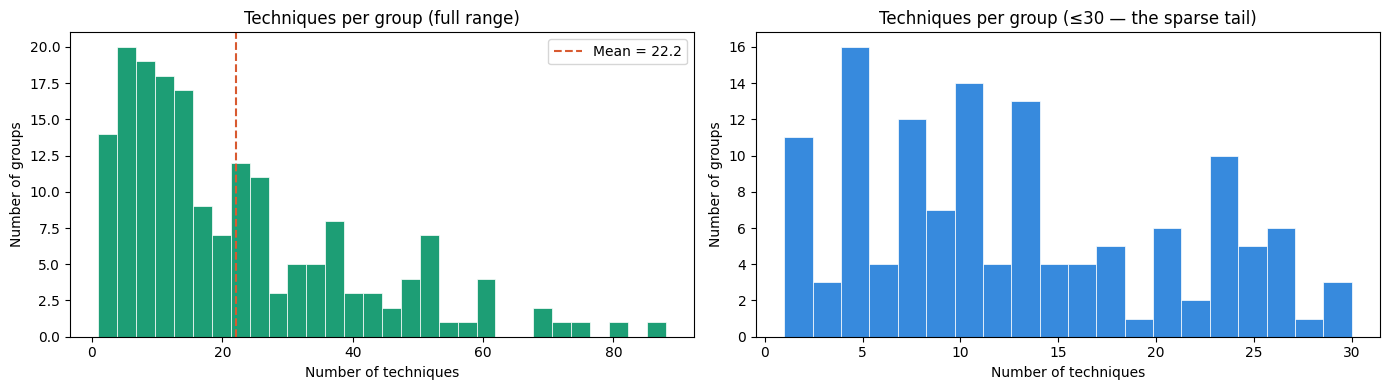

Saved → artifacts/technique_distribution.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(count_vals, bins=30, color="#1D9E75", edgecolor="white", linewidth=0.5)
axes[0].set_title("Techniques per group (full range)", fontsize=12)
axes[0].set_xlabel("Number of techniques")
axes[0].set_ylabel("Number of groups")
axes[0].axvline(np.mean(count_vals), color="#D85A30", linestyle="--", label=f"Mean = {np.mean(count_vals):.1f}")
axes[0].legend()

axes[1].hist([c for c in count_vals if c <= 30], bins=20, color="#378ADD", edgecolor="white", linewidth=0.5)
axes[1].set_title("Techniques per group (≤30 — the sparse tail)", fontsize=12)
axes[1].set_xlabel("Number of techniques")
axes[1].set_ylabel("Number of groups")

plt.tight_layout()
plt.savefig(ARTIFACTS / "technique_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → artifacts/technique_distribution.png")

In [31]:
# ── feature vocab: all unique technique IDs across all groups ─
all_technique_ids = sorted({tid for techs in group_techniques.values() for tid in techs})
feature_vocab     = {tid: idx for idx, tid in enumerate(all_technique_ids)}

# ── label encoder: group name → integer class ─────────────────
group_names = sorted(
    groups_clean[gid]["name"]
    for gid in group_techniques
)
label_encoder = LabelEncoder()
label_encoder.fit(group_names)

print(f"Feature dimensions : {len(feature_vocab):>5}  (unique technique IDs after root-only collapse)")
print(f"Classes (groups)   : {len(label_encoder.classes_):>5}")
print(f"\nFirst 3 label encoded groups:")
count = 0

for group, label in zip(label_encoder.classes_,
                        label_encoder.transform(label_encoder.classes_)):
    print(group, "->", label)

    count += 1
    if count == 3:
        break
print(f"\nFirst 10 features  : {all_technique_ids[:10]}")
print(f"First 5 classes    : {list(label_encoder.classes_[:5])}")


Feature dimensions :   204  (unique technique IDs after root-only collapse)
Classes (groups)   :   179

First 3 label encoded groups:
APT-C-36 -> 0
APT1 -> 1
APT12 -> 2

First 10 features  : ['T1001', 'T1003', 'T1005', 'T1006', 'T1007', 'T1008', 'T1010', 'T1012', 'T1014', 'T1016']
First 5 classes    : [np.str_('APT-C-36'), np.str_('APT1'), np.str_('APT12'), np.str_('APT16'), np.str_('APT17')]


In [32]:
import numpy as np
import random

X = []
y = []

for gid, techs in group_techniques.items():

    techs = list(techs)

    if len(techs) < 3:
        continue

    group_name = groups_clean[gid]["name"]

    # har group ke 30 samples banao
    for _ in range(30):

        k = random.randint(
            max(2, len(techs)//3),
            len(techs)
        )

        selected = random.sample(techs, k)

        vec = np.zeros(len(feature_vocab), dtype=np.float32)

        for tid in selected:
            if tid in feature_vocab:
                vec[feature_vocab[tid]] = 1

        X.append(vec)
        y.append(group_name)

X = np.array(X)

print("Total Samples :", len(X))
print("Total Classes :", len(set(y)))
print("Feature Count :", X.shape[1])
print("Shape :", X.shape)

Total Samples : 5040
Total Classes : 168
Feature Count : 204
Shape : (5040, 204)


In [33]:
print("Matrix Shape =", X.shape)
print("X =", X.shape)
print("y =", len(y))



Matrix Shape = (5040, 204)
X = (5040, 204)
y = 5040


In [34]:
import pandas as pd

feature_names = sorted(feature_vocab.keys())

df = pd.DataFrame(X, columns=feature_names)

df["group"] = y

print(df.shape)
df.head()

(5040, 205)


,T1001,T1003,T1005,T1006,T1007,T1008,T1010,T1012,T1014,T1016,...,T1679,T1680,T1681,T1682,T1683,T1684,T1685,T1686,T1690,group
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APT1
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APT1
2,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APT1
3,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APT1
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,APT1


In [16]:
# Spot-check: APT28 (well-known group with many techniques)
probe_name = None
for name in label_encoder.classes_:
    if "APT28" in name:
        probe_name = name
        break
if probe_name:
    idx  = label_encoder.transform([probe_name])[0]
    row  = X[idx]
    tids = [all_technique_ids[i] for i, v in enumerate(row) if v > 0]
    print(f"Probe group : {probe_name}")
    print(f"Techniques  : {len(tids)}")
    print(f"Sample IDs  : {tids[:10]}")
else:
    print("APT28 not found under that name — check label_encoder.classes_ manually")


Probe group : APT28
Techniques  : 15
Sample IDs  : ['T1003', 'T1005', 'T1007', 'T1021', 'T1036', 'T1049', 'T1057', 'T1059', 'T1114', 'T1119']


In [36]:
import joblib

joblib.dump(X, ARTIFACTS / "X.joblib")
joblib.dump(y, ARTIFACTS / "y.joblib")
joblib.dump(feature_vocab, ARTIFACTS / "feature_vocab.joblib")

print("Artifacts saved successfully")
print("X shape:", X.shape)
print("Samples:", len(y))

Artifacts saved successfully
X shape: (5040, 204)
Samples: 5040
